In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train_features = pd.read_csv('dengue_features_train.csv')
train_labels = pd.read_csv('dengue_labels_train.csv')

In [4]:
train_features.shape

(1456, 24)

In [5]:
train_labels.shape

(1456, 4)

In [6]:
train_labels.columns

Index(['city', 'year', 'weekofyear', 'total_cases'], dtype='object')

In [7]:
train_features.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm'],
      dtype='object')

In [8]:
import pandas as pd
eda_Df = pd.merge(
    train_features,
    train_labels,
    on=['city', 'year', 'weekofyear'],
    how='left'
)
eda_Df.isnull().sum().sort_values(ascending=False).head(10)

ndvi_ne                    194
ndvi_nw                     52
station_avg_temp_c          43
station_diur_temp_rng_c     43
station_precip_mm           22
ndvi_se                     22
ndvi_sw                     22
station_max_temp_c          20
station_min_temp_c          14
precipitation_amt_mm        13
dtype: int64

In [9]:
eda_Df.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [10]:
eda_Df.shape

(1456, 25)

In [11]:
eda_Df['total_cases'].describe()

count    1456.000000
mean       24.675137
std        43.596000
min         0.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       461.000000
Name: total_cases, dtype: float64

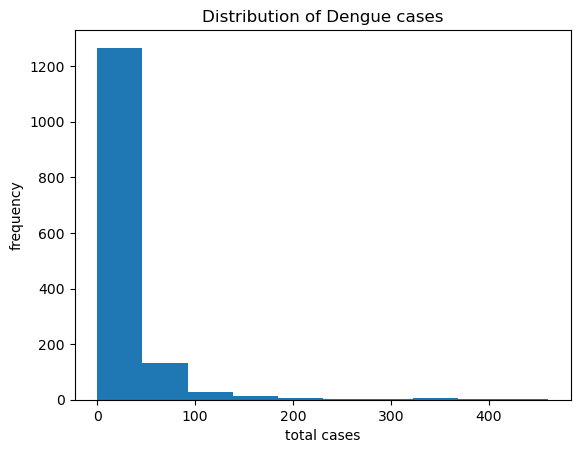

In [12]:
plt.Figure(figsize=(8,4))
plt.hist(eda_Df['total_cases'], bins=10)
plt.title('Distribution of Dengue cases')
plt.xlabel('total cases')
plt.ylabel('frequency')
plt.show()

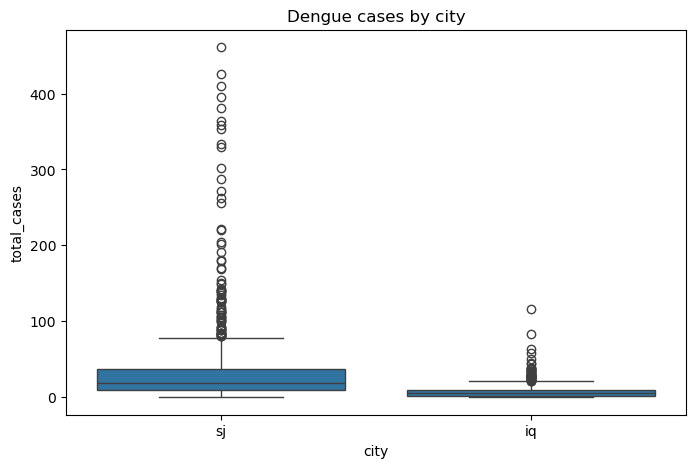

In [13]:
eda_Df.groupby('city')['total_cases'].describe()
import seaborn as sns
plt.figure(figsize=(8,5))
sns.boxplot(data=eda_Df, x='city', y='total_cases')
plt.title('Dengue cases by city')
plt.show()

San juan experiences most frequent out breaks compare to iquitos

In [14]:
eda_Df['city'].value_counts()

city
sj    936
iq    520
Name: count, dtype: int64

This dataset is slightly imbalanced with San juan having significantly more records than Iquitos. This indicates that dengue patterns should be analyzed separately for each city to avoid bias caused by unequal temporal coverage.

In [15]:
eda_Df['week_start_date'] = pd.to_datetime(eda_Df['week_start_date'])
eda_Df.groupby('city')['week_start_date'].agg(['min', 'max'])

,min,max
city,,
iq,2000-07-01,2010-06-25
sj,1990-04-30,2008-04-22


In [19]:
eda_Df = eda_Df.sort_values(
    by= ['city', 'year', 'weekofyear']
)
eda_Df['casesLag1'] = (eda_Df.groupby('city')['total_cases'].shift(1))
eda_Df['casesLag2'] = (eda_Df.groupby('city')['total_cases'].shift(2))
eda_Df['casesLag3'] = (eda_Df.groupby('city')['total_cases'].shift(3))
eda_Df[['total_cases', 'casesLag1', 'casesLag2', 'casesLag3']].corr()


,total_cases,casesLag1,casesLag2,casesLag3
total_cases,1.000000,0.954644,0.910070,0.860731
casesLag1,0.954644,1.000000,0.954632,0.910038
casesLag2,0.910070,0.954632,1.000000,0.954618
casesLag3,0.860731,0.910038,0.954618,1.000000


The dengue case counts show strong positive autocorrelation up to at least 3 weeks, indicating persistent outbreak behavior and strong temporal dependency. Since this data also exhibits high multicollinearity as well then I think we should rule out the regression or linear models.

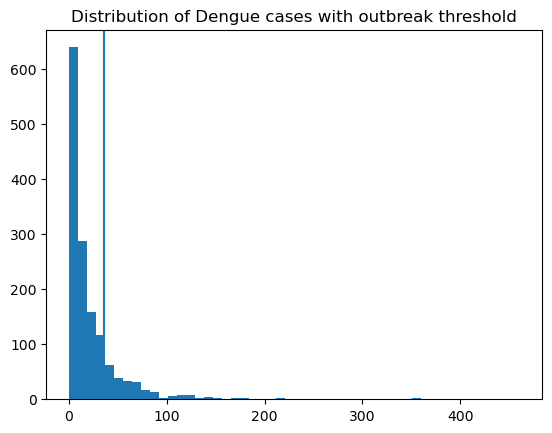

In [26]:
q1 = eda_Df['total_cases'].quantile(0.25)
q3 = eda_Df['total_cases'].quantile(0.75)
iqr = q3-q1
upper_bound = q3 + 1.5*q1
extreme_week = eda_Df[eda_Df['total_cases']>upper_bound]
extreme_week.shape
plt.figure
plt.hist(eda_Df['total_cases'], bins =50)
plt.axvline(upper_bound)
plt.title('Distribution of Dengue cases with outbreak threshold')
plt.show()

Using the IQR-based outlier threshold, we identified statistically extreme outbreak weeks. These weeks are concentrated primarily in San Juan and represent rare but intense epidemic periods. The heavy right skew of the distribution confirms that dengue case counts are characterized by sporadic outbreak spikes rather than steady behavior.

In [ ]:
zero_weeks = eda_Df[eda_Df['total_cases'] == 0]
zero_percentage = (len(zero_weeks)/len(eda_Df)) * 100
near_or_less_5 = eda_Df[eda_Df['total_cases'] <= 5]
near_or_less_5_percentage = (len(near_or_less_5)/len(eda_Df)) * 100
print(near_or_less_5_percentage)

29.120879120879124


In [ ]:
eda_Df.groupby('city')['total_cases'].apply(
    lambda x: (x<=5).mean()*100
)

city
iq    57.115385
sj    13.568376
Name: total_cases, dtype: float64

Iquitos exhibits a high proportion of low-activity weeks (57%), indicating intermittent transmission patterns, whereas San Juan shows sustained dengue activity with only 13% near-zero weeks. This suggests fundamentally different outbreak dynamics between the two cities.

In [37]:
eda_Df = eda_Df.sort_values(['city', 'year', 'weekofyear'])

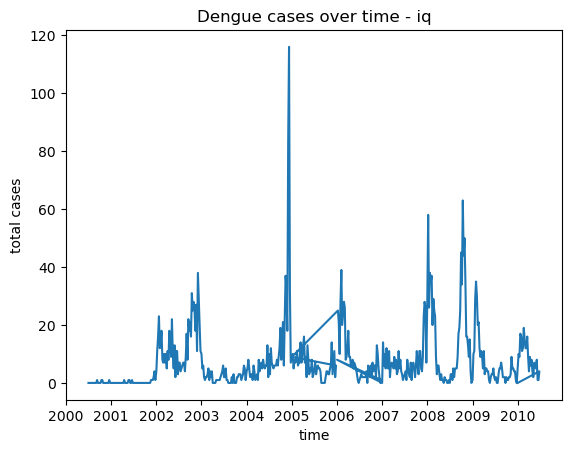

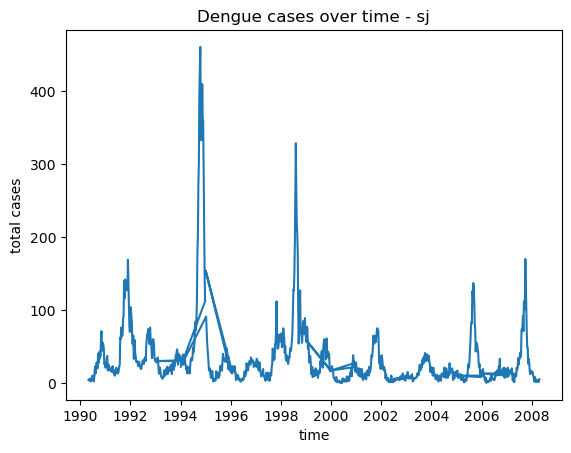

In [43]:
for city in eda_Df['city'].unique():
    city_df = eda_Df[eda_Df['city'] == city]

    plt.figure()
    plt.plot(city_df['week_start_date'], city_df['total_cases'])
    plt.title(f'Dengue cases over time - {city}')
    plt.xlabel('time')
    plt.ylabel('total cases')
    plt.show()

The temporal evolution of dengue cases reveals strong seasonality and persistence in San Juan, characterized by recurring annual peaks. In contrast, Iquitos exhibits prolonged low-activity periods punctuated by intermittent outbreak spikes, suggesting more irregular transmission dynamics.

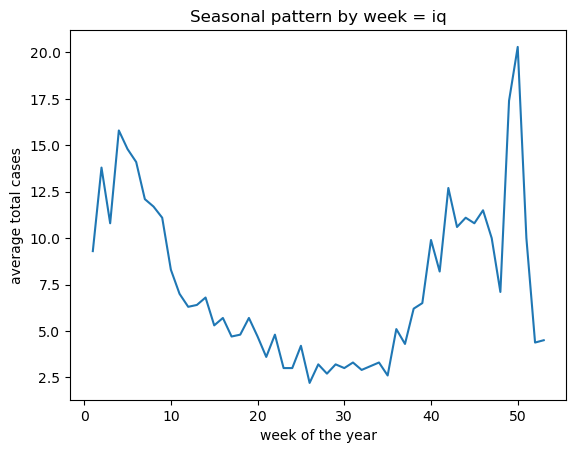

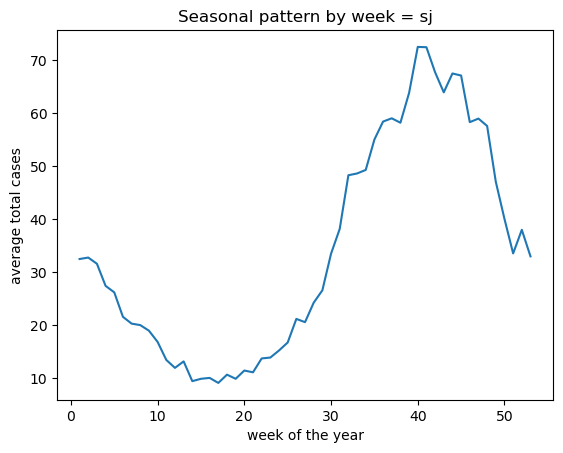

In [51]:
seasonality_citywise = (
    eda_Df
    .groupby(['city','weekofyear'])['total_cases']
    .mean()
    .reset_index()
)
for city in seasonality_citywise['city'].unique():
    city_df = seasonality_citywise[seasonality_citywise['city'] == city]

    plt.Figure(figsize=(10,8))
    plt.plot(city_df['weekofyear'], city_df['total_cases'])
    plt.title(f'Seasonal pattern by week = {city}')
    plt.xlabel('week of the year')
    plt.ylabel('average total cases')
    # plt.tight_layout()
    plt.show()



Both cities exhibit seasonal behavior in weekly dengue cases. San Juan demonstrates a strong and consistent annual seasonal cycle with a pronounced peak around weeks 35–40, whereas Iquitos shows weaker and more irregular seasonal fluctuations with smaller amplitude peaks. This suggests more structured endemic transmission in San Juan and intermittent outbreak dynamics in Iquitos.

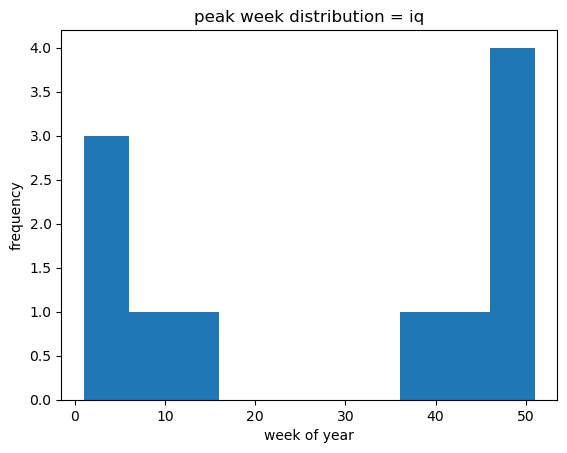

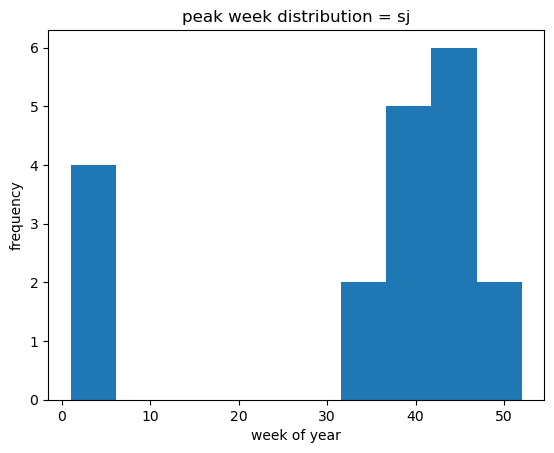

In [55]:
peak_weeks = (
    eda_Df.loc[
        eda_Df.groupby(['city', 'year'])['total_cases'].idxmax()
    ][['city', 'year', 'weekofyear','total_cases']]
)
for city in peak_weeks['city'].unique():
    city_df = peak_weeks[peak_weeks['city'] == city]

    plt.Figure()
    plt.hist(city_df['weekofyear'], bins = 10)
    plt.xlabel('week of year')
    plt.ylabel('frequency')
    plt.title(f'peak week distribution = {city}')
    plt.show()

San Juan exhibits strong temporal regularity in outbreak timing, with peak dengue activity consistently occurring between weeks 35 and 45. In contrast, Iquitos demonstrates greater variability in peak timing across years, indicating weaker seasonal synchronization and potentially stronger dependence on stochastic environmental drivers.

In [57]:
eda_Df.groupby(['city','year'])['total_cases'].sum().reset_index()


,city,year,total_cases
0,iq,2000,4
1,iq,2001,14
2,iq,2002,704
3,iq,2003,114
4,iq,2004,638
5,iq,2005,311
6,iq,2006,436
7,iq,2007,365
8,iq,2008,801
9,iq,2009,324


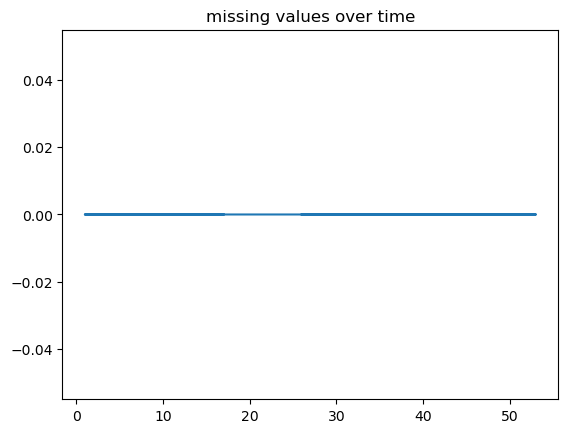

In [62]:
eda_Df['missing_val'] = eda_Df['total_cases'].isnull().astype(int)
plt.figure()
plt.plot(eda_Df['weekofyear'], eda_Df['missing_val'])
plt.title('missing values over time')
plt.show()

In [66]:
weather_cols = [
    'reanalysis_air_temp_k',
    'reanalysis_avg_temp_k',
    'reanalysis_min_air_temp_k',
    'reanalysis_max_air_temp_k',
    'reanalysis_precip_amt_kg_per_m2',
    'station_precip_mm',
    'ndvi_ne',
    'ndvi_nw',
    'ndvi_se',
    'ndvi_sw'
]
corr = eda_Df[weather_cols + ['total_cases']].corr()
corr['total_cases'].sort_values(ascending= False)

total_cases                        1.000000
reanalysis_min_air_temp_k          0.325252
reanalysis_air_temp_k              0.264952
reanalysis_avg_temp_k              0.151637
reanalysis_precip_amt_kg_per_m2   -0.010031
station_precip_mm                 -0.074374
ndvi_se                           -0.168612
reanalysis_max_air_temp_k         -0.191345
ndvi_sw                           -0.196461
ndvi_nw                           -0.202235
ndvi_ne                           -0.241376
Name: total_cases, dtype: float64

In [68]:
corr = eda_Df.corr(numeric_only= True)
corr['total_cases'].sort_values(ascending= False)

total_cases                              1.000000
casesLag1                                0.954644
casesLag2                                0.910070
casesLag3                                0.860731
reanalysis_min_air_temp_k                0.325252
station_min_temp_c                       0.267109
reanalysis_air_temp_k                    0.264952
weekofyear                               0.216452
reanalysis_avg_temp_k                    0.151637
reanalysis_dew_point_temp_k              0.142531
reanalysis_specific_humidity_g_per_kg    0.129861
station_avg_temp_c                       0.116109
reanalysis_precip_amt_kg_per_m2         -0.010031
precipitation_amt_mm                    -0.038740
reanalysis_sat_precip_amt_mm            -0.038740
station_max_temp_c                      -0.039219
station_precip_mm                       -0.074374
reanalysis_relative_humidity_percent    -0.132452
ndvi_se                                 -0.168612
reanalysis_max_air_temp_k               -0.191345


In [70]:
for city in eda_Df['city'].unique():
    print(f'\nCity: {city}')
    city_corr = eda_Df[eda_Df['city'] == city].corr(numeric_only = True)
    print(city_corr['total_cases'].sort_values(ascending = False))


City: iq
total_cases                              1.000000
casesLag1                                0.746124
casesLag2                                0.586278
casesLag3                                0.546575
reanalysis_specific_humidity_g_per_kg    0.236476
reanalysis_dew_point_temp_k              0.230401
reanalysis_min_air_temp_k                0.214514
station_min_temp_c                       0.211702
year                                     0.179451
reanalysis_relative_humidity_percent     0.130083
station_avg_temp_c                       0.113070
reanalysis_precip_amt_kg_per_m2          0.101171
reanalysis_air_temp_k                    0.097098
reanalysis_sat_precip_amt_mm             0.090171
precipitation_amt_mm                     0.090171
reanalysis_avg_temp_k                    0.079872
station_max_temp_c                       0.075279
station_precip_mm                        0.042976
ndvi_sw                                  0.032999
ndvi_ne                                 

In [61]:
eda_Df.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases', 'casesLag1',
       'casesLag2', 'casesLag3', 'missing_val'],
      dtype='object')